# 01 — Pipeline validation on E1A

End-to-end validation of the processing pipeline using E1A (supine pre-sleep,
5-min analysis window).

**Two processing paths compared side-by-side:**

| path  | filter    | detection                      | correction                        | HRV                              |
|-------|-----------|--------------------------------|-----------------------------------|----------------------------------|
| scipy | filter_ecg | detect_qrs (Pan-Tompkins port) | reject_artifacts 300–2000 ms      | time_domain + frequency_domain   |
| NK2   | filter_ecg | detect_qrs_nk (ecg_peaks)      | signal_fixpeaks (Kubios iterative)| compute_hrv_full (~95 indices)   |

**Expected (competitive swimmer, supine):**
- Mean HR 50-65 bpm
- SDNN >= 50 ms
- Dominant HF peak in 0.2-0.3 Hz band
- EDR rate consistent across peak-detection and Welch-peak methods

In [1]:
from __future__ import annotations

import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import config as cfg
from src import pipeline as P
from src import plotting as PL

PL.apply_style()
warnings.filterwarnings('ignore', category=RuntimeWarning)

FIG_DIR = REPO_ROOT / 'outputs' / 'figures'
TBL_DIR = REPO_ROOT / 'outputs' / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)
print('Setup complete. Sessions available:', len(cfg.SESSION_MAP))

Setup complete. Sessions available: 14


## 0. Figure 1: Project map, dual-path validation, and downstream analyses


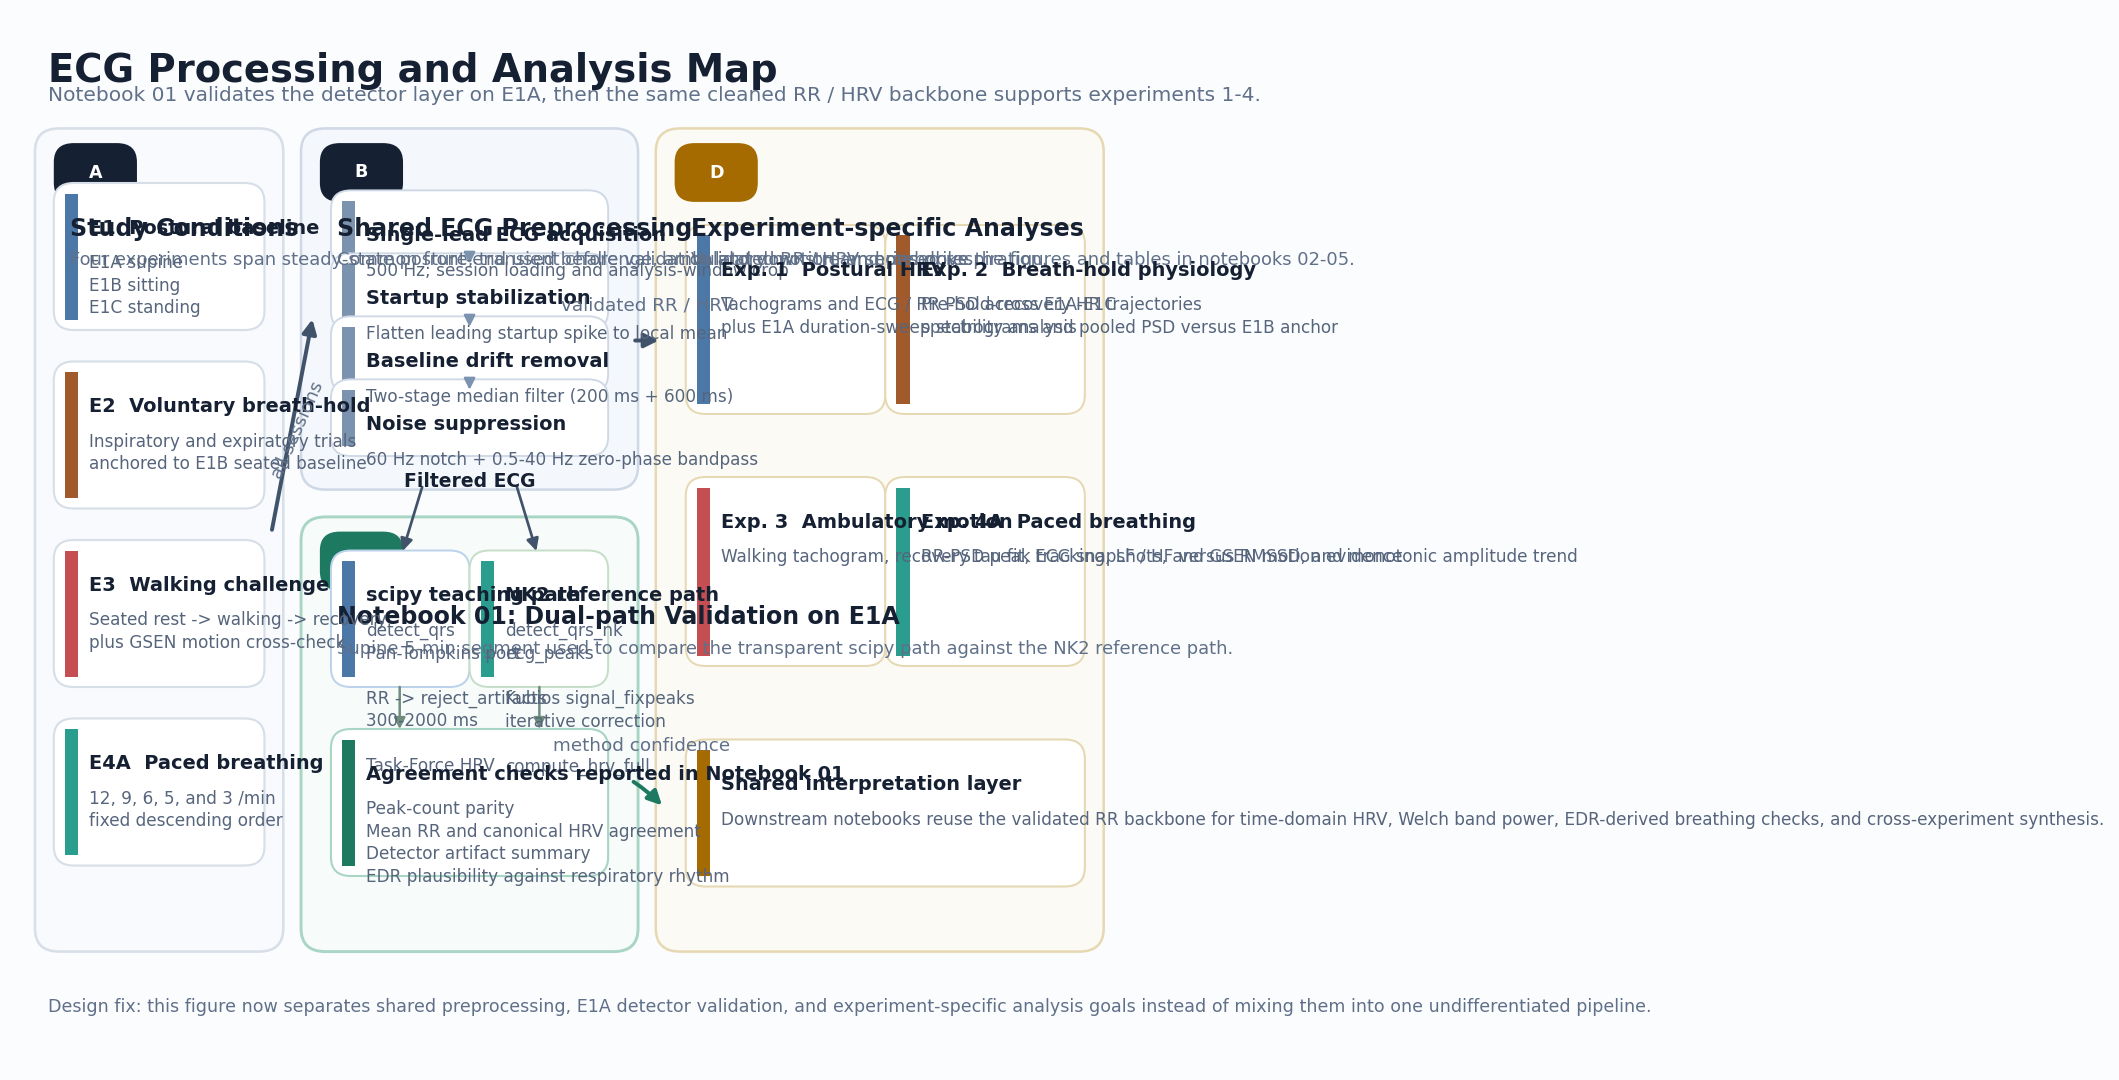

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Rectangle

def _panel(ax, x, y, w, h, title, subtitle="", *,
           fc="#FFFFFF", ec="#D7DEE8", lw=1.2,
           title_color="#162033", subtitle_color="#607089",
           label=None, label_fc="#162033", rounding=0.022):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle=f"round,pad=0.012,rounding_size={rounding}",
        linewidth=lw,
        edgecolor=ec,
        facecolor=fc,
    )
    ax.add_patch(patch)
    if label:
        pill = FancyBboxPatch(
            (x + 0.015, y + h - 0.048), 0.055, 0.036,
            boxstyle="round,pad=0.01,rounding_size=0.018",
            linewidth=0,
            facecolor=label_fc,
            edgecolor=label_fc,
        )
        ax.add_patch(pill)
        ax.text(x + 0.0425, y + h - 0.03, label,
                ha="center", va="center", fontsize=8.4,
                fontweight="bold", color="white")
    ax.text(x + 0.02, y + h - 0.072, title,
            ha="left", va="top", fontsize=11.4,
            fontweight="bold", color=title_color)
    if subtitle:
        ax.text(x + 0.02, y + h - 0.105, subtitle,
                ha="left", va="top", fontsize=8.6,
                color=subtitle_color)
    return patch


def _card(ax, x, y, w, h, title, body, *,
          fc="#F8FAFC", ec="#CCD5E1", title_color="#162033",
          body_color="#56657C", accent=None, lw=1.0):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.010,rounding_size=0.018",
        linewidth=lw,
        edgecolor=ec,
        facecolor=fc,
    )
    ax.add_patch(patch)
    if accent:
        ax.add_patch(Rectangle((x, y), 0.012, h, linewidth=0, facecolor=accent))
    ax.text(x + 0.022, y + h - 0.024, title,
            ha="left", va="top", fontsize=9.3,
            fontweight="bold", color=title_color)
    ax.text(x + 0.022, y + h - 0.058, body,
            ha="left", va="top", fontsize=8.1,
            color=body_color, linespacing=1.32)
    return patch


def _arrow(ax, start, end, *, color="#41526B", lw=1.8, scale=13,
           connectionstyle="arc3"):
    ax.add_patch(
        FancyArrowPatch(
            start, end,
            arrowstyle="-|>",
            mutation_scale=scale,
            linewidth=lw,
            color=color,
            shrinkA=5,
            shrinkB=5,
            connectionstyle=connectionstyle,
        )
    )


def draw_pipeline_overview():
    PL.apply_style()

    fig = plt.figure(figsize=(13.2, 7.3), dpi=150, facecolor="#FBFCFE")
    ax = fig.add_subplot(111)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    palette = {
        "ink": "#162033",
        "muted": "#607089",
        "line": "#41526B",
        "study_bg": "#F8FAFD",
        "study_edge": "#D6DEE8",
        "shared_bg": "#F4F7FB",
        "shared_edge": "#CFD8E5",
        "valid_bg": "#F7FBF9",
        "valid_edge": "#A8D5C4",
        "valid_accent": "#1D7A61",
        "down_bg": "#FCFAF4",
        "down_edge": "#E5D8B2",
        "down_accent": "#A56A00",
        "exp1": "#4C78A8",
        "exp2": "#A05A2C",
        "exp3": "#C44E52",
        "exp4": "#2A9D8F",
    }

    ax.text(0.03, 0.965, "ECG Processing and Analysis Map",
            ha="left", va="top", fontsize=18.5,
            fontweight="bold", color=palette["ink"])
    ax.text(
        0.03, 0.932,
        "Notebook 01 validates the detector layer on E1A, then the same cleaned RR / HRV backbone supports experiments 1-4.",
        ha="left", va="top", fontsize=9.7, color=palette["muted"]
    )

    _panel(
        ax, 0.03, 0.12, 0.20, 0.76,
        "Study Conditions",
        "Four experiments span steady-state posture, transient challenge, ambulatory motion, and paced respiration.",
        fc=palette["study_bg"], ec=palette["study_edge"],
        label="A", label_fc=palette["ink"]
    )
    _panel(
        ax, 0.27, 0.56, 0.28, 0.32,
        "Shared ECG Preprocessing",
        "Common front-end used before validation and downstream notebooks.",
        fc=palette["shared_bg"], ec=palette["shared_edge"],
        label="B", label_fc=palette["ink"]
    )
    _panel(
        ax, 0.27, 0.12, 0.28, 0.39,
        "Notebook 01: Dual-path Validation on E1A",
        "Supine 5-min segment used to compare the transparent scipy path against the NK2 reference path.",
        fc=palette["valid_bg"], ec=palette["valid_edge"],
        label="C", label_fc=palette["valid_accent"], lw=1.4
    )
    _panel(
        ax, 0.59, 0.12, 0.38, 0.76,
        "Experiment-specific Analyses",
        "Validated RR / HRV series drive the figures and tables in notebooks 02-05.",
        fc=palette["down_bg"], ec=palette["down_edge"],
        label="D", label_fc=palette["down_accent"]
    )

    study_cards = [
        ("E1  Postural baseline", "E1A supine\nE1B sitting\nE1C standing", palette["exp1"]),
        ("E2  Voluntary breath-hold", "Inspiratory and expiratory trials\nanchored to E1B seated baseline", palette["exp2"]),
        ("E3  Walking challenge", "Seated rest -> walking -> recovery\nplus GSEN motion cross-check", palette["exp3"]),
        ("E4A  Paced breathing", "12, 9, 6, 5, and 3 /min\nfixed descending order", palette["exp4"]),
    ]
    study_y = [0.71, 0.54, 0.37, 0.20]
    for y, (title, body, accent) in zip(study_y, study_cards):
        _card(
            ax, 0.045, y, 0.17, 0.12, title, body,
            fc="#FFFFFF", ec=palette["study_edge"], accent=accent
        )

    step_y = [0.77, 0.71, 0.65, 0.59]
    steps = [
        ("Single-lead ECG acquisition", "500 Hz; session loading and analysis-window crop"),
        ("Startup stabilization", "Flatten leading startup spike to local mean"),
        ("Baseline drift removal", "Two-stage median filter (200 ms + 600 ms)"),
        ("Noise suppression", "60 Hz notch + 0.5-40 Hz zero-phase bandpass"),
    ]
    for y, (title, body) in zip(step_y, steps):
        _card(
            ax, 0.295, y, 0.23, 0.053, title, body,
            fc="#FFFFFF", ec=palette["shared_edge"], accent="#7C93B0", lw=0.9
        )
    for y0, y1 in zip(step_y[:-1], step_y[1:]):
        _arrow(ax, (0.41, y0), (0.41, y1 + 0.053), color="#7C93B0", lw=1.2, scale=11)

    ax.text(0.41, 0.565, "Filtered ECG",
            ha="center", va="top", fontsize=9.0,
            fontweight="bold", color=palette["ink"])

    _card(
        ax, 0.295, 0.37, 0.105, 0.11,
        "scipy teaching path",
        "detect_qrs\nPan-Tompkins port\n\nRR -> reject_artifacts\n300-2000 ms\n\nTask-Force HRV",
        fc="#FFFFFF", ec="#BCD2EA", accent=palette["exp1"], lw=0.95
    )
    _card(
        ax, 0.42, 0.37, 0.105, 0.11,
        "NK2 reference path",
        "detect_qrs_nk\necg_peaks\n\nKubios signal_fixpeaks\niterative correction\n\ncompute_hrv_full",
        fc="#FFFFFF", ec="#C6DEC8", accent=palette["exp4"], lw=0.95
    )
    _arrow(ax, (0.37, 0.56), (0.347, 0.48), color=palette["line"], lw=1.3, scale=12)
    _arrow(ax, (0.45, 0.56), (0.473, 0.48), color=palette["line"], lw=1.3, scale=12)

    _card(
        ax, 0.295, 0.19, 0.23, 0.12,
        "Agreement checks reported in Notebook 01",
        "Peak-count parity\nMean RR and canonical HRV agreement\nDetector artifact summary\nEDR plausibility against respiratory rhythm",
        fc="#FFFFFF", ec=palette["valid_edge"], accent=palette["valid_accent"], lw=1.0
    )
    _arrow(ax, (0.347, 0.37), (0.347, 0.31), color="#6E8D7D", lw=1.2, scale=11)
    _arrow(ax, (0.473, 0.37), (0.473, 0.31), color="#6E8D7D", lw=1.2, scale=11)

    downstream_cards = [
        (
            0.615, 0.63, 0.16, 0.16,
            "Exp. 1  Postural HRV",
            "Tachograms and ECG / RR PSD across E1A-E1C\nplus E1A duration-sweep stability analysis",
            palette["exp1"],
        ),
        (
            0.795, 0.63, 0.16, 0.16,
            "Exp. 2  Breath-hold physiology",
            "Pre-hold-recovery HR trajectories\nspectrograms and pooled PSD versus E1B anchor",
            palette["exp2"],
        ),
        (
            0.615, 0.39, 0.16, 0.16,
            "Exp. 3  Ambulatory motion",
            "Walking tachogram, recovery tau fit, ECG snapshots, and GSEN motion evidence",
            palette["exp3"],
        ),
        (
            0.795, 0.39, 0.16, 0.16,
            "Exp. 4A  Paced breathing",
            "RR-PSD peak tracking, LF / HF versus RMSSD, and monotonic amplitude trend",
            palette["exp4"],
        ),
    ]
    for x, y, w, h, title, body, accent in downstream_cards:
        _card(
            ax, x, y, w, h, title, body,
            fc="#FFFFFF", ec=palette["down_edge"], accent=accent, lw=0.95
        )

    _card(
        ax, 0.615, 0.18, 0.34, 0.12,
        "Shared interpretation layer",
        "Downstream notebooks reuse the validated RR backbone for time-domain HRV, Welch band power, EDR-derived breathing checks, and cross-experiment synthesis.",
        fc="#FFFFFF", ec=palette["down_edge"], accent=palette["down_accent"], lw=1.0
    )

    _arrow(ax, (0.23, 0.50), (0.27, 0.72), color=palette["line"], lw=1.9, scale=14)
    ax.text(0.255, 0.605, "all sessions", ha="center", va="center",
            fontsize=8.8, color=palette["muted"], rotation=66)

    _arrow(ax, (0.55, 0.69), (0.59, 0.69), color=palette["line"], lw=1.9, scale=14)
    ax.text(0.57, 0.715, "validated RR / HRV", ha="center", va="bottom",
            fontsize=8.8, color=palette["muted"])

    _arrow(ax, (0.55, 0.275), (0.59, 0.24), color=palette["valid_accent"],
           lw=1.9, scale=14, connectionstyle="arc3,rad=-0.08")
    ax.text(0.565, 0.295, "method confidence", ha="center", va="bottom",
            fontsize=8.8, color=palette["muted"])

    ax.text(
        0.03, 0.055,
        "Design fix: this figure now separates shared preprocessing, E1A detector validation, and experiment-specific analysis goals instead of mixing them into one undifferentiated pipeline.",
        ha="left", va="center", fontsize=8.4, color=palette["muted"]
    )

    fig.tight_layout()
    PL.save_figure(fig, "nb01_fig01_pipeline_overview.pdf")
    plt.show()


draw_pipeline_overview()


## 1. Load + filter

In [3]:
key = "E1A"
t, ecg_raw = P.load_ecg(key, ch=1)
ecg_f = P.filter_ecg(ecg_raw)
print(f"{key}: {ecg_raw.size} samples = {ecg_raw.size/cfg.FS:.1f}s")

E1A: 150000 samples = 300.0s


## 2. scipy Pan-Tompkins path

In [4]:
peaks_s = P.detect_qrs(ecg_f)
rr_s, rt_s = P.compute_rr(peaks_s)
rr_s, rt_s, n_rej = P.reject_artifacts(rr_s, rt_s)
td_scipy = P.time_domain_hrv(rr_s)
fd_scipy = P.frequency_domain_hrv(rr_s, rt_s)
print(f"scipy: {peaks_s.size} peaks, {n_rej} RR rejected")
print(f"  Mean HR = {td_scipy['mean_hr_bpm']:.1f} bpm")
print(f"  SDNN    = {td_scipy['sdnn_ms']:.1f} ms")
print(f"  RMSSD   = {td_scipy['rmssd_ms']:.1f} ms")

scipy: 269 peaks, 0 RR rejected
  Mean HR = 54.0 bpm
  SDNN    = 81.5 ms
  RMSSD   = 99.1 ms


## 3. NeuroKit2 path (authoritative)

In [5]:
peaks_nk, nk_stats = P.detect_qrs_nk(ecg_f)
rr_nk, rt_nk = P.compute_rr(peaks_nk)
hrv_full = P.compute_hrv_full(peaks_nk)
print("NK2 peak-detection stats:")
for k, v in nk_stats.items():
    print(f"  {k:20s}: {v}")
print(f"\ncompute_hrv_full: shape={hrv_full.shape}  (indices={hrv_full.shape[1]})")

NK2 peak-detection stats:
  n_peaks_raw         : 268
  n_peaks_corrected   : 268
  ectopic             : 0
  missed              : 0
  extra               : 0
  longshort           : 1
  method              : nk.ecg_peaks + signal_fixpeaks(kubios, iterative=True)

compute_hrv_full: shape=(1, 95)  (indices=95)


## 4. Peak agreement between paths

In [6]:
# Match peaks within a 100 ms window for a fair agreement count
tol = int(0.10 * cfg.FS)
matched = 0
i_nk = 0
for p in peaks_s:
    while i_nk < peaks_nk.size and peaks_nk[i_nk] < p - tol:
        i_nk += 1
    if i_nk < peaks_nk.size and abs(peaks_nk[i_nk] - p) <= tol:
        matched += 1
agreement = 100.0 * matched / max(peaks_s.size, peaks_nk.size)
print(f"scipy peaks: {peaks_s.size}   NK2 peaks: {peaks_nk.size}")
print(f"Matched within {tol} samples (+/-100ms): {matched}")
print(f"Agreement: {agreement:.1f} %")

scipy peaks: 269   NK2 peaks: 268
Matched within 50 samples (+/-100ms): 268
Agreement: 99.6 %


## 5. Side-by-side HRV comparison

In [7]:
# Canonical overlap indices
comp_rows = [
    ("Mean RR (ms)",  td_scipy["mean_rr_ms"],
     float(hrv_full["HRV_MeanNN"].iloc[0]) if "HRV_MeanNN" in hrv_full else np.nan),
    ("Mean HR (bpm)", td_scipy["mean_hr_bpm"],
     60000.0 / float(hrv_full["HRV_MeanNN"].iloc[0]) if "HRV_MeanNN" in hrv_full else np.nan),
    ("SDNN (ms)",     td_scipy["sdnn_ms"],
     float(hrv_full["HRV_SDNN"].iloc[0])  if "HRV_SDNN" in hrv_full  else np.nan),
    ("RMSSD (ms)",    td_scipy["rmssd_ms"],
     float(hrv_full["HRV_RMSSD"].iloc[0]) if "HRV_RMSSD" in hrv_full else np.nan),
    ("pNN50 (%)",     td_scipy["pnn50_pct"],
     float(hrv_full["HRV_pNN50"].iloc[0]) if "HRV_pNN50" in hrv_full else np.nan),
    ("LF/HF (ratio)", fd_scipy["lf_hf_ratio"],
     float(hrv_full["HRV_LFHF"].iloc[0])  if "HRV_LFHF" in hrv_full  else np.nan),
]
df_cmp = pd.DataFrame(comp_rows, columns=["metric", "scipy", "NK2"])
df_cmp["abs_delta"] = (df_cmp["scipy"] - df_cmp["NK2"]).abs()
df_cmp["rel_delta_pct"] = 100.0 * df_cmp["abs_delta"] / df_cmp[["scipy","NK2"]].abs().mean(axis=1)
df_cmp.style.set_caption("E1A — scipy vs NeuroKit2 HRV indices (overlap)").format(
    {"scipy":"{:.2f}","NK2":"{:.2f}","abs_delta":"{:.2f}","rel_delta_pct":"{:.2f}"})

,metric,scipy,NK2,abs_delta,rel_delta_pct
0,Mean RR (ms),1116.94,1117.90,0.96,0.09
1,Mean HR (bpm),54.02,53.67,0.35,0.65
2,SDNN (ms),81.54,79.89,1.65,2.05
3,RMSSD (ms),99.13,96.45,2.68,2.74
4,pNN50 (%),62.17,60.67,1.50,2.44
5,LF/HF (ratio),0.28,0.27,0.01,3.65


## 6. Pipeline assertions (swimmer-supine expectations)

In [8]:
mean_hr = td_scipy["mean_hr_bpm"]
sdnn    = td_scipy["sdnn_ms"]
print(f"Mean HR = {mean_hr:.1f} bpm (expected 50-65)")
print(f"SDNN    = {sdnn:.1f} ms (expected >= 50)")
assert 50.0 <= mean_hr <= 70.0, f"Mean HR out of range: {mean_hr:.1f}"
assert sdnn >= 50.0, f"SDNN below swimmer-supine threshold: {sdnn:.1f}"
print("OK")

Mean HR = 54.0 bpm (expected 50-65)
SDNN    = 81.5 ms (expected >= 50)
OK


## 7. EDR dual-method breathing-rate cross-check

In [9]:
edr = P.derive_respiration_from_ecg(ecg_f)
print(f"Peak-detection rate: {edr['rate_bpm']:.2f} bpm = {edr['rate_hz']:.4f} Hz")
print(f"Welch PSD peak:      {edr['welch_peak_hz']*60:.2f} bpm = {edr['welch_peak_hz']:.4f} Hz")
delta_bpm = abs(edr["rate_bpm"] - edr["welch_peak_hz"] * 60.0)
print(f"|Δ| = {delta_bpm:.2f} bpm")
assert delta_bpm < 4.0, "EDR methods disagree by more than 4 bpm"
assert 10.0 <= edr["rate_bpm"] <= 22.0, "Spontaneous breathing rate outside 10-22 bpm"
print("EDR cross-check OK")

Peak-detection rate: 13.39 bpm = 0.2231 Hz
Welch PSD peak:      14.00 bpm = 0.2333 Hz
|Δ| = 0.61 bpm
EDR cross-check OK


## 8. Overview figure

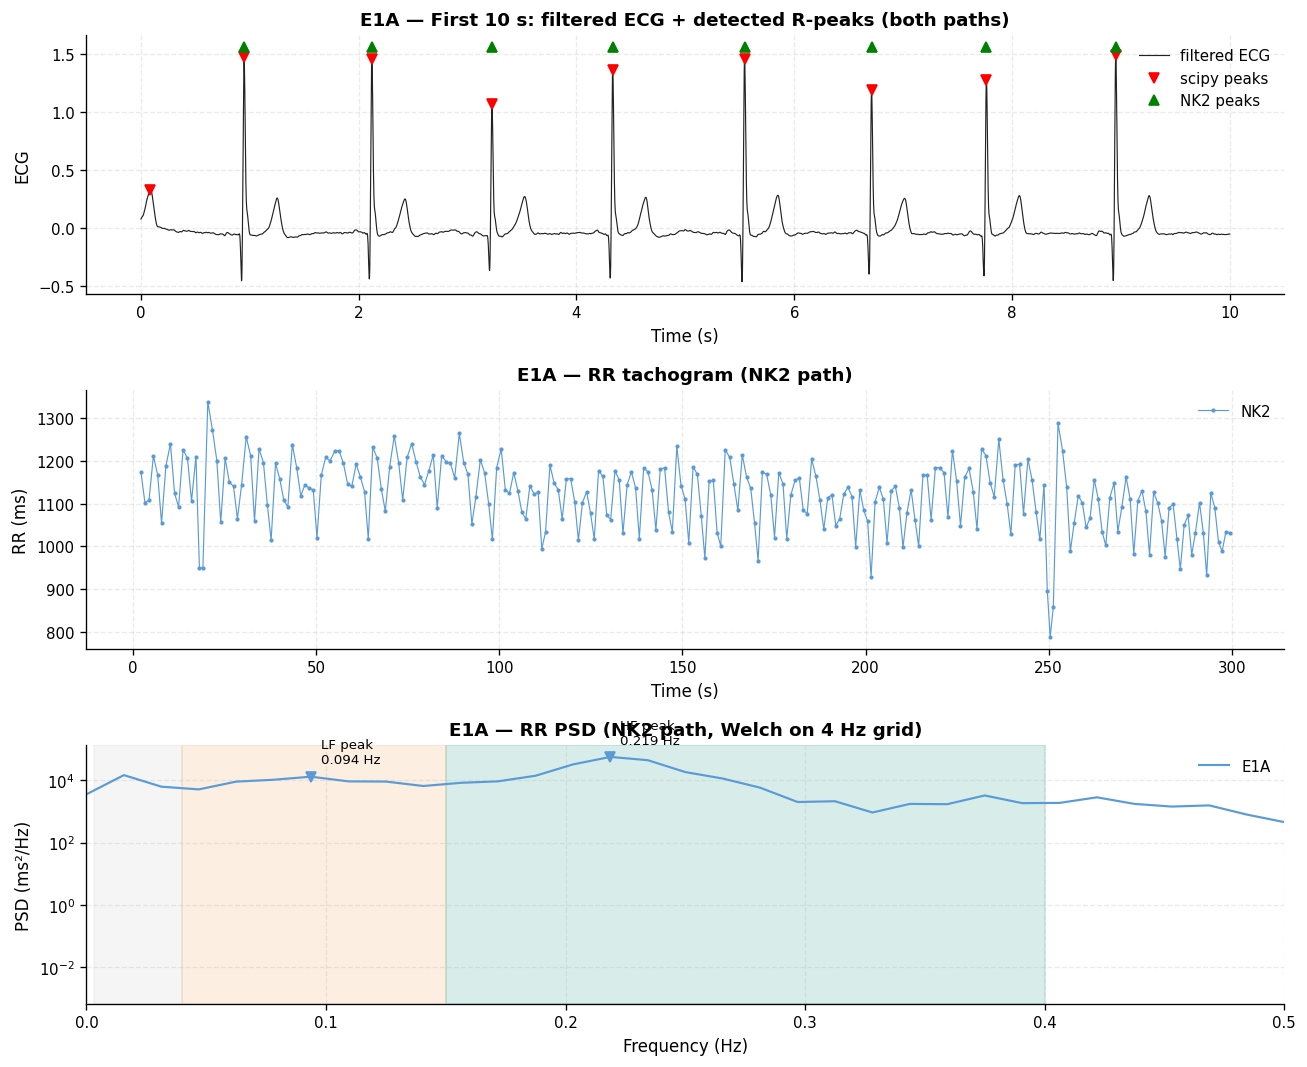

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9))
seg = slice(0, int(10 * cfg.FS))

axes[0].plot(t[seg], ecg_f[seg], color="#222", linewidth=0.7, label="filtered ECG")
p_in = peaks_s[peaks_s < seg.stop]
axes[0].plot(t[p_in], ecg_f[p_in], "rv", markersize=6, label="scipy peaks")
p_in_nk = peaks_nk[peaks_nk < seg.stop]
axes[0].plot(t[p_in_nk], ecg_f[p_in_nk] * 0 + ecg_f[p_in_nk].max() * 1.05,
             "g^", markersize=6, label="NK2 peaks")
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("ECG")
axes[0].set_title("E1A — First 10 s: filtered ECG + detected R-peaks (both paths)")
axes[0].legend(loc="upper right")

PL.plot_rr_tachogram(rr_nk, rt_nk, ax=axes[1],
                     color=PL.STYLE_COLORS[key],
                     title="E1A — RR tachogram (NK2 path)",
                     label="NK2")

f, p = P.rr_psd(rr_nk, rt_nk)
PL.plot_rr_psd_pub(f, p, ax=axes[2], color=PL.STYLE_COLORS[key],
                   title="E1A — RR PSD (NK2 path, Welch on 4 Hz grid)",
                   label="E1A")
fig.tight_layout()
PL.save_figure(fig, "nb01_fig02_e1a_validation.png")
plt.show()

## 9. Save validation table

In [11]:
# Write full 95-index HRV CSV and the comparison table
hrv_full.insert(0, "key", key)
hrv_full.to_csv(TBL_DIR / "e1a_hrv_full.csv", index=False)
df_cmp.to_csv(TBL_DIR / "e1a_pipeline_comparison.csv", index=False)
print(f"Wrote {TBL_DIR/'e1a_hrv_full.csv'}")
print(f"Wrote {TBL_DIR/'e1a_pipeline_comparison.csv'}")

Wrote /Users/wupeien/Developer/hw5_ecg-analysis/outputs/tables/e1a_hrv_full.csv
Wrote /Users/wupeien/Developer/hw5_ecg-analysis/outputs/tables/e1a_pipeline_comparison.csv
